# OBS004 — The Local JWST Environment of ASPECS C19

## Scientific Objective

The goal of this investigation is to characterize the galaxy environment surrounding the ASPECS source **C19** using deep JWST NIRCam F200W imaging.

Building on the measurements completed in **OBS003**, this notebook expands the field of view around C19 in order to:

- identify nearby galaxies,
- locate neighboring ASPECS CO detections,
- investigate possible physical companions,
- search for evidence of interactions or galaxy group membership,
- compare the stellar environments of C19 and nearby CO-selected galaxies.

Particular attention will be given to **CO ID 1**, whose proximity to C19 suggests it may provide important insight into the local environment.

---

## Expected Products

- Large JWST cutouts surrounding C19
- Catalog of nearby galaxies
- Identification of CO counterparts
- Environmental measurements
- Publication-quality figures

In [4]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

import astropy.units as u

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch
)

from astropy.table import Table

In [5]:
# ==========================================================
# Notebook Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT = Path.cwd().parent

# Add the project root to Python's import path
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

print("Project root:")
print(PROJECT)

Project root:
/home/glenn/Projects/CosmicIntelligenceLab


In [6]:
# ==========================================================
# Project Paths
# ==========================================================

DATA = PROJECT / "data"

CATALOGS = DATA / "catalogs"
IMAGERY = DATA / "imagery"

FIGURES = PROJECT / "figures" / "obs004"
DOCS = PROJECT / "docs" / "observations"

FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Catalogs : {CATALOGS}")
print(f"Figures  : {FIGURES}")

Catalogs : /home/glenn/Projects/CosmicIntelligenceLab/data/catalogs
Figures  : /home/glenn/Projects/CosmicIntelligenceLab/figures/obs004


import cosmic.catalogs as cc

print(cc.__file__)

print([name for name in dir(cc) if not name.startswith("_")])

In [7]:
import cosmic.catalogs as cc

print(cc.__file__)
['JADES_FILENAME', 'Path', 'SkyCoord', 'Table', 'build_jades_coordinates', 'cone_search_jades', 'join', 'load_jades_table', 'load_working_jades_catalog', 'select_jades_core_columns', 'u']
print()

print([name for name in dir(cc) if not name.startswith("_")])

/home/glenn/Projects/CosmicIntelligenceLab/cosmic/catalogs.py

['JADES_FILENAME', 'Path', 'SkyCoord', 'Table', 'build_jades_coordinates', 'cone_search_jades', 'join', 'load_jades_table', 'load_working_jades_catalog', 'select_jades_core_columns', 'u']


In [8]:
# ==========================================================
# Target Information
# ==========================================================

c19 = SkyCoord(
    "03h32m38.53s",
    "-27d46m34.6s",
    frame="icrs"
)

print(c19)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.16054167, -27.77627778)>


# Phase 1 — Load the JWST F200W Mosaic

Load the calibrated JADES F200W mosaic that was identified and downloaded during OBS003.

This notebook begins with the existing science image rather than repeating the archive search performed previously.

In [9]:
# ==========================================================
# Phase 1
# Load JWST Science Image
# ==========================================================

jwst_file = (
    DATA
    / "raw"
    / "jwst"
    / "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

hdul = fits.open(jwst_file)

hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     280   ()      
  1  SCI           1 ImageHDU        75   (9884, 4386)   float32   
  2  ERR           1 ImageHDU        10   (9884, 4386)   float32   
  3  CON           1 ImageHDU        10   (9884, 4386, 2)   int32   
  4  WHT           1 ImageHDU         9   (9884, 4386)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (9884, 4386)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (9884, 4386)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (9884, 4386)   float32   
  8  HDRTAB        1 BinTableHDU    536   48R x 263C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 104A, 13A, 2A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 11A, 1A, 5A, D, D, D, D, D, D, D, D, 6A, 5A, 1A, 

In [10]:
# ==========================================================
# Phase 1
# Prepare Image and WCS
# ==========================================================

jwst_image = hdul["SCI"].data

jwst_wcs = WCS(
    hdul["SCI"].header
)

jwst_norm = ImageNormalize(
    jwst_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

print(jwst_image.shape)

Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(4386, 9884)


In [11]:
# ==========================================================
# Phase 2
# Create a Large JWST Cutout
# ==========================================================

large_size = (800, 800)

large_cutout = Cutout2D(
    data=jwst_image,
    position=c19,
    size=large_size,
    wcs=jwst_wcs
)

print("Cutout shape:", large_cutout.data.shape)

Cutout shape: (800, 800)


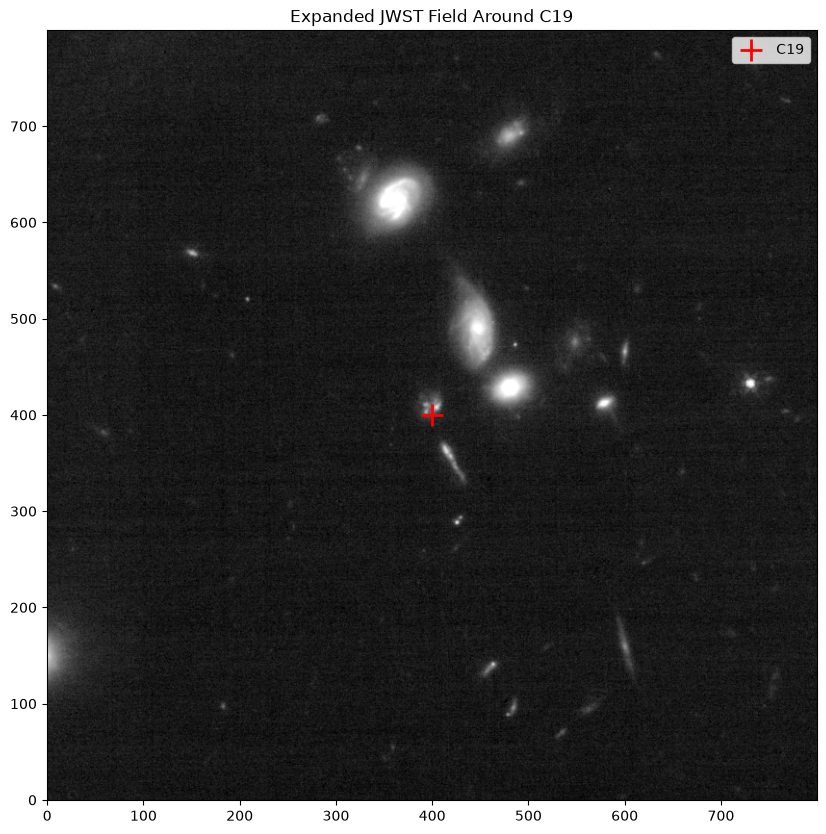

In [12]:
# ==========================================================
# Phase 2
# Display the Expanded JWST Field
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# C19 lies at the center of the cutout
ax.scatter(
    400,
    400,
    marker="+",
    s=250,
    color="red",
    linewidths=2,
    label="C19"
)

ax.set_title("Expanded JWST Field Around C19")

ax.legend()

plt.show()

In [13]:
# ==========================================================
# Phase 3
# Load the ASPECS CO Catalog
# ==========================================================

catalog = Table.read(
    CATALOGS / "aspecs_co_catalog.ecsv"
)

print(f"Number of CO sources: {len(catalog)}")

catalog[:5]

Number of CO sources: 18


id,ra,dec,z,jup,snr
str4,str11,str12,float64,int64,float64
1,03:32:38.54,-27:46:34.62,2.543,3,37.7
2,03:32:42.38,-27:47:07.92,1.317,2,17.9
3,03:32:41.02,-27:46:31.56,2.453,3,15.8
4,03:32:34.44,-27:46:59.82,1.414,2,15.5
5,03:32:39.76,-27:46:11.58,1.55,2,15.0


In [14]:
# ==========================================================
# Phase 3
# Convert CO Catalog to JWST Pixel Coordinates
# ==========================================================

co_coords = SkyCoord(
    catalog["ra"],
    catalog["dec"],
    unit=(u.hourangle, u.deg),
    frame="icrs"
)

co_x, co_y = large_cutout.wcs.world_to_pixel(co_coords)

# ==========================================================
# Extract C19 Position
# ==========================================================

# C19 is the first entry in the ASPECS catalog
c19_index = 0

c19_x = co_x[c19_index]
c19_y = co_y[c19_index]

print(f"C19 pixel position: ({c19_x:.2f}, {c19_y:.2f})")

# C19 is the first ASPECS catalog entry
c19_x = co_x[0]
c19_y = co_y[0]

print(f"C19 pixel position: ({c19_x:.2f}, {c19_y:.2f})")

# Keep only sources inside the 800×800 cutout
inside = (
    (co_x >= 0)
    & (co_x < large_cutout.data.shape[1])
    & (co_y >= 0)
    & (co_y < large_cutout.data.shape[0])
)

print(f"Sources inside cutout: {inside.sum()} of {len(catalog)}")

print(f"Sources inside field: {inside.sum()} of {len(catalog)}")

print(f"Converted {len(co_coords)} catalog positions.")

C19 pixel position: (395.58, 402.04)
C19 pixel position: (395.58, 402.04)
Sources inside cutout: 1 of 18
Sources inside field: 1 of 18
Converted 18 catalog positions.


/home/glenn/Projects/CosmicIntelligenceLab/figures/obs004/fig2_c19_jwst_aspecs_catalog_overlay.png


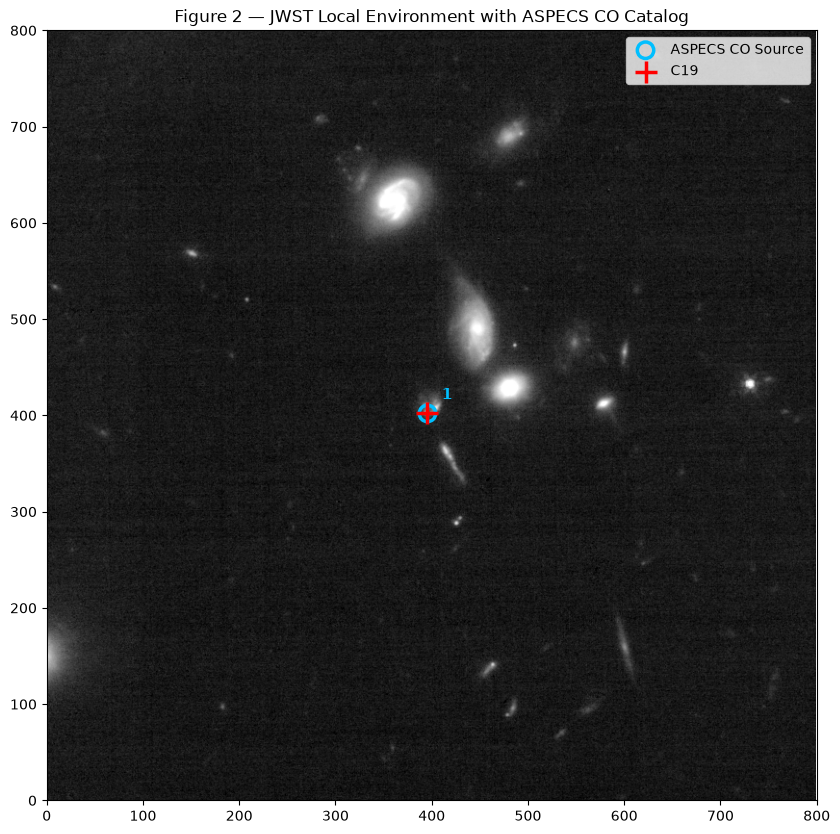

In [15]:
# ==========================================================
# Figure 2
# JWST Local Environment with ASPECS CO Catalog
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

# JWST image
ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# Plot ONLY the sources inside the cutout
ax.scatter(
    co_x[inside],
    co_y[inside],
    s=140,
    facecolors="none",
    edgecolors="deepskyblue",
    linewidths=2.5,
    label="ASPECS CO Source"
)

# Label them
for source_id, xpix, ypix in zip(
    catalog["id"][inside],
    co_x[inside],
    co_y[inside],
):
    ax.text(
        xpix + 15,
        ypix + 15,
        str(source_id),
        color="deepskyblue",
        fontsize=11,
        weight="bold"
    )

# Mark C19
ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    color="red",
    s=250,
    linewidths=2.5,
    label="C19"
)

ax.set_xlim(0, large_cutout.data.shape[1])
ax.set_ylim(0, large_cutout.data.shape[0])

ax.set_title("Figure 2 — JWST Local Environment with ASPECS CO Catalog")

ax.legend()
['JADES_FILENAME', 'Path', 'SkyCoord', 'Table', 'build_jades_coordinates', 'cone_search_jades', 'join', 'load_jades_table', 'load_working_jades_catalog', 'select_jades_core_columns', 'u']
outfile = FIGURES / "fig2_c19_jwst_aspecs_catalog_overlay.png"

fig.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

print(outfile)

plt.show()

In [16]:
# ==========================================================
# Phase 4
# Candidate Neighboring Galaxies
# ==========================================================

neighbors = {
    "A": (365, 620),
    "B": (450, 490),
    "C": (500, 425),
    "D": (425, 350),
    "E": (585, 410),
    "F": (480, 690),
    "G": (475, 425),   # Bright compact galaxy
}

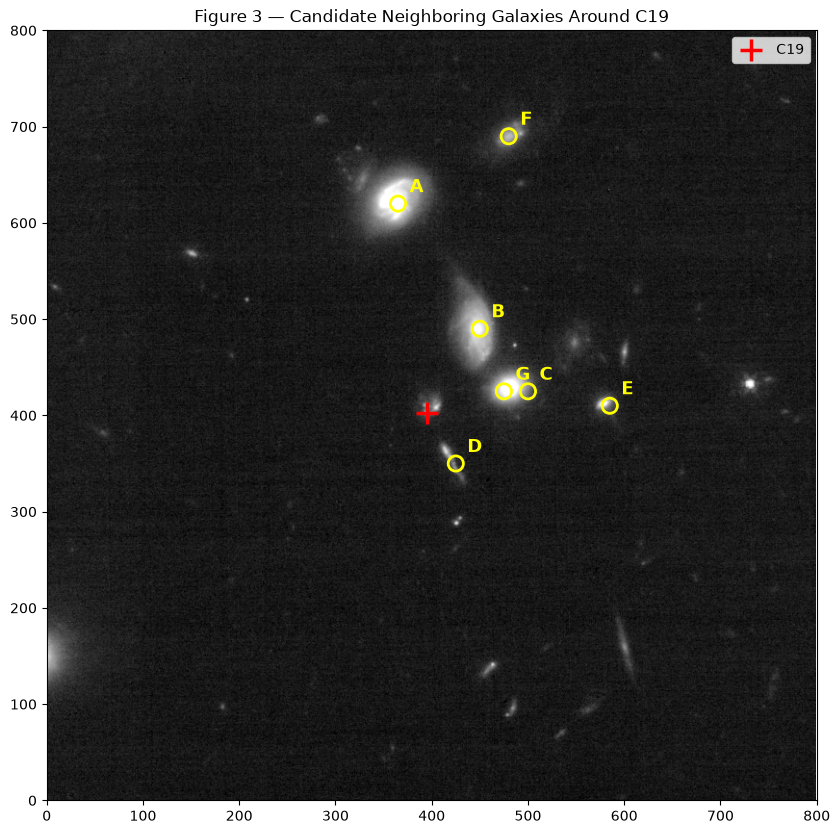

In [17]:
# ==========================================================
# Figure 3
# Candidate Neighboring Galaxies
# ==========================================================

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

#
# Mark C19
#
ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    s=250,
    color="red",
    linewidths=2.5,
    label="C19"
)

#
# Candidate neighbors
#
for label, (x, y) in neighbors.items():

    ax.scatter(
        x,
        y,
        s=120,
        facecolors="none",
        edgecolors="yellow",
        linewidths=2
    )

    ax.text(
        x + 12,
        y + 12,
        label,
        color="yellow",
        fontsize=13,
        weight="bold"
    )

ax.set_xlim(0, 800)
ax.set_ylim(0, 800)

ax.set_title("Figure 3 — Candidate Neighboring Galaxies Around C19")

ax.legend()

outfile = FIGURES / "fig3_c19_candidate_neighboring_galaxies.png"

fig.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ==========================================================
# Phase 5
# Convert Candidate Pixels to Sky Coordinates
# ==========================================================

candidate_coords = {}

for label, (x, y) in neighbors.items():

    sky = large_cutout.wcs.pixel_to_world(x, y)

    candidate_coords[label] = sky

    print(
        f"{label}: "
        f"RA={sky.ra.deg:.6f}°   "
        f"Dec={sky.dec.deg:.6f}°"
    )

A: RA=53.162303°   Dec=-27.775131°
B: RA=53.160814°   Dec=-27.775410°
C: RA=53.160017°   Dec=-27.775503°
D: RA=53.160019°   Dec=-27.776423°
E: RA=53.159322°   Dec=-27.775075°
F: RA=53.161988°   Dec=-27.773997°
G: RA=53.160190°   Dec=-27.775656°


In [19]:
# ==========================================================
# Phase 5
# Candidate Environment Table
# ==========================================================

from astropy.table import Table

environment = Table(
    names=[
        "Label",
        "RA_deg",
        "Dec_deg",
        "JADES_ID",
        "z_spec",
        "z_phot",
        "ALMA",
        "Notes",
    ],
    dtype=[
        "U2",
        float,
        float,
        "U32",
        float,
        float,
        "U10",
        "U80",
    ]
)

for label, sky in candidate_coords.items():

    environment.add_row([
        label,
        sky.ra.deg,
        sky.dec.deg,
        "",
        np.nan,
        np.nan,
        "",
        ""
    ])

environment

Label,RA_deg,Dec_deg,JADES_ID,z_spec,z_phot,ALMA,Notes
str2,float64,float64,str32,float64,float64,str10,str80
A,53.16230328033456,-27.775130613941744,,nan,nan,,
B,53.16081358085944,-27.77540960130518,,nan,nan,,
C,53.16001662025412,-27.77550319190905,,nan,nan,,
D,53.16001895997571,-27.77642320402161,,nan,nan,,
E,53.15932231785185,-27.77507523127794,,nan,nan,,
F,53.16198842926671,-27.773996558186457,,nan,nan,,
G,53.16019031376619,-27.77565618213005,,nan,nan,,


# Phase 5A — Acquire the JADES Reference Catalog

The local environment of C19 will be investigated using the official
JADES Data Release 5 (DR5) photometric catalog.

This catalog provides:

- Source identifiers
- Accurate celestial coordinates
- Multi-band photometry
- Photometric redshifts
- Additional derived source properties

The catalog will become a permanent reference dataset for the
Cosmic Intelligence Lab.

In [20]:
# ==========================================================
# Phase 5A
# Locate the JADES Reference Catalog
# ==========================================================

JADES = CATALOGS / "jades" / "dr5"

assert JADES.exists(), "JADES catalog directory not found."

print("JADES catalog:")
print(JADES)

JADES catalog:
/home/glenn/Projects/CosmicIntelligenceLab/data/catalogs/jades/dr5


# Phase 6

Visual Identification of JADES Counterparts

In [21]:
# ==========================================================
# Phase 6A
# Ten Nearest JADES Sources
# ==========================================================

nearest_jades_ids = [
    209117,
    209116,
    400187,
    400199,
    128606,
    312982,
    400194,
    389334,
    812948,
    265671,
]

print(nearest_jades_ids)

[209117, 209116, 400187, 400199, 128606, 312982, 400194, 389334, 812948, 265671]


In [22]:
# ==========================================================
# Phase 6B
# Load the Candidate JADES Sources
# ==========================================================

import numpy as np

from cosmic.catalogs import (
    load_jades_table,
    select_jades_core_columns,
)

# Load only the tables we need
kron = load_jades_table(PROJECT, "KRON")
photoz = load_jades_table(PROJECT, "PHOTOZ")

# Build the working catalog
from astropy.table import join

jades = join(
    kron,
    photoz,
    keys="ID",
    join_type="left",
)

# Keep only the core columns
jades_core = select_jades_core_columns(jades)

print(f"Loaded {len(jades_core):,} JADES sources.")

Cosmic Intelligence Lab
Loading JADES table: KRON
Rows    : 304,366
Columns : 225

Cosmic Intelligence Lab
Loading JADES table: PHOTOZ
Rows    : 304,366
Columns : 34

Loaded 304,366 JADES sources.


In [23]:
# ==========================================================
# Phase 6C
# Build the Core JADES Catalog
# ==========================================================

from cosmic.catalogs import select_jades_core_columns

jades_core = select_jades_core_columns(jades)

print()
print(f"Core catalog contains {len(jades_core):,} galaxies.")
print()

print(jades_core.colnames)


Core catalog contains 304,366 galaxies.

['ID', 'RA', 'DEC', 'A_KRON', 'B_KRON', 'THETA_KRON', 'z_spec', 'z_peak', 'z_ml']


In [24]:
# ==========================================================
# Phase 6D
# Extract the Candidate JADES Sources
# ==========================================================

import numpy as np

candidate_ids = [
    209117,
    209116,
    400187,
    400199,
    128606,
    312982,
    400194,
    389334,
    812948,
    265671,
]

candidates = jades_core[
    np.isin(jades_core["ID"], candidate_ids)
]

print(f"Found {len(candidates)} candidate galaxies.")

candidates

Found 10 candidate galaxies.


ID,RA,DEC,A_KRON,B_KRON,THETA_KRON,z_spec,z_peak,z_ml
,deg,deg,arcsec,arcsec,deg,,,
int64,float64,float64,float64,float64,float64,float64,float64,float32
128606,53.160625,-27.77673,0.28912896184458164,0.2553051633946566,-50.955273,-9999.0,3.429999828338623,3.429114
209116,53.160187,-27.77641,0.9519935026750774,0.42060753702405856,-14.51835,-9999.0,2.809999942779541,2.808533
209117,53.160614,-27.776264,0.999825559954577,0.8327602713602331,-60.609272,-9999.0,3.7899999618530273,3.7894702
265671,53.161053,-27.776834,0.3774817654127915,0.15981212694309013,-55.811363,-9999.0,3.9499998092651367,3.946196
312982,53.16096,-27.776669,0.27571413282470475,0.2201926521222002,9.49382,-9999.0,3.9499998092651367,3.952183
389334,53.160454,-27.776861,0.3011920575535302,0.19851539929997558,-83.04955,-9999.0,5.039999961853027,5.0372806
400187,53.16073,-27.776619,0.3070742427562191,0.2906380416622722,-29.391737,-9999.0,3.3399999141693115,3.3353567
400194,53.161137,-27.776106,0.6570983498600738,0.3390364854767548,41.68376,-9999.0,1.459999918937683,1.4563897


In [25]:
# ==========================================================
# Phase 6E
# Build Sky Coordinates for Candidate Galaxies
# ==========================================================

from cosmic.catalogs import build_jades_coordinates

candidate_coords = build_jades_coordinates(candidates)

print(f"Created {len(candidate_coords)} sky coordinates.")

Created 10 sky coordinates.


In [26]:
# ==========================================================
# Phase 6F
# Convert Sky Coordinates to Pixel Coordinates
# ==========================================================

candidate_x, candidate_y = large_cutout.wcs.world_to_pixel(
    candidate_coords
)

print("Converted candidate positions to image pixels.")

Converted candidate positions to image pixels.


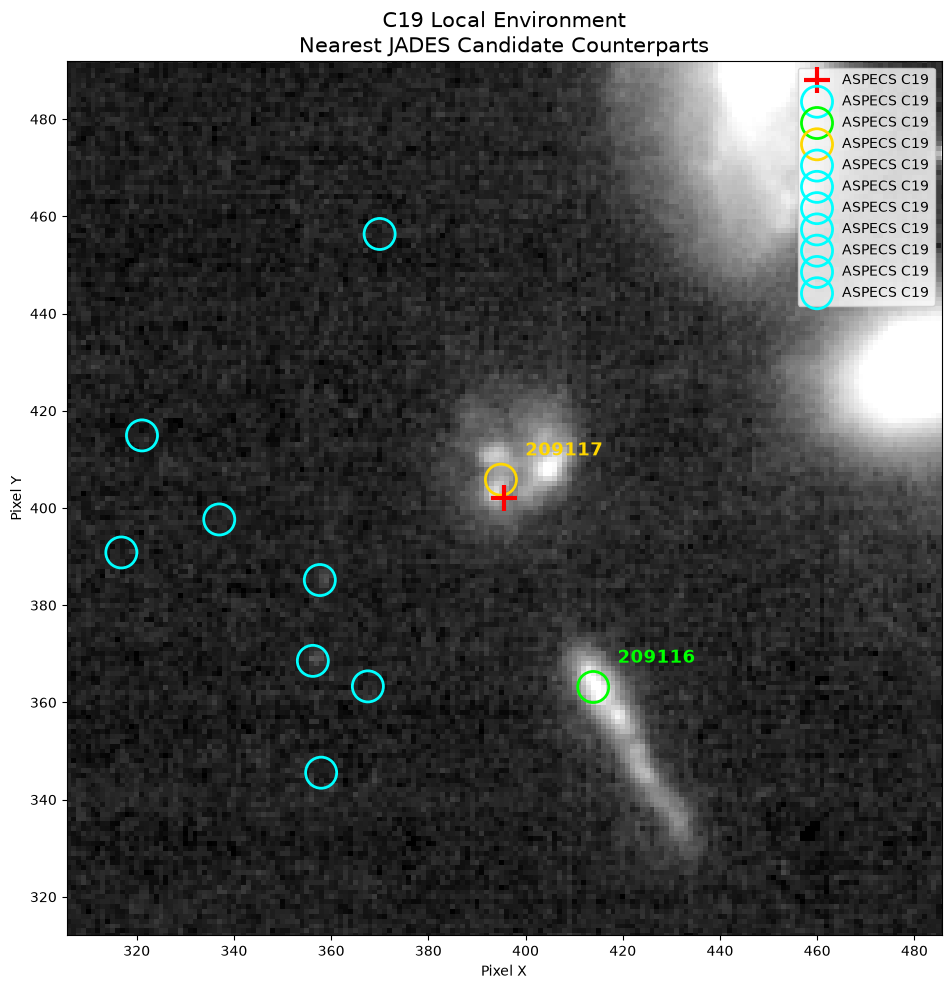

In [44]:
# ==========================================================
# Phase 6G
# C19 and the Nearest JADES Candidate Counterparts
# ==========================================================

import matplotlib.pyplot as plt

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# Normalize the JWST image
# ----------------------------------------------------------

norm = ImageNormalize(
    large_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Create the figure
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# Plot the ASPECS C19 position
# ----------------------------------------------------------

ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    s=350,
    color="red",
    linewidths=3,
    zorder=10,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# Plot the JADES candidate galaxies
# ----------------------------------------------------------

for row, xpix, ypix in zip(
    candidates,
    candidate_x,
    candidate_y,
):

    source_id = row["ID"]

    if source_id == 209117:
        color = "gold"

    elif source_id == 209116:
        color = "lime"

    else:
        color = "cyan"

    ax.scatter(
        xpix,
        ypix,
        s=500,
        facecolors="none",
        edgecolors=color,
        linewidths=2,
        zorder=5,
        label="ASPECS C19",
    )

    if source_id in (209117, 209116):
        ax.text(
            xpix + 5,
            ypix + 5,
            str(source_id),
            color=color,
            fontsize=13,
            weight="bold",
            zorder=6,
    )

# ----------------------------------------------------------
# Zoom around the C19 position
# ----------------------------------------------------------

half_width = 90

ax.set_xlim(c19_x - half_width, c19_x + half_width)
ax.set_ylim(c19_y - half_width, c19_y + half_width)

# ----------------------------------------------------------
# Figure cosmetics
# ----------------------------------------------------------

ax.set_title(
    "C19 Local Environment\nNearest JADES Candidate Counterparts",
    fontsize=15,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()

plt.show()

In [41]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

# Pixel scale in arcsec/pixel
pixel_scale_arcsec = (
    proj_plane_pixel_scales(large_cutout.wcs)[0]
    * u.deg
).to(u.arcsec).value

print(f"Pixel scale: {pixel_scale_arcsec:.4f} arcsec/pixel")

Pixel scale: 0.0312 arcsec/pixel


In [42]:
from matplotlib.patches import Circle

radius_pixels = 30 / pixel_scale_arcsec

circle = Circle(
    (c19_x, c19_y),
    radius_pixels,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
    linewidth=1.5,
)

ax.add_patch(circle)

In [43]:
# ==========================================================
# Phase 6H
# Save Figure
# ==========================================================

filename = (
    FIGURES
    / "fig4_c19_jades_candidate_counterparts.png"
)

fig.savefig(
    filename,
    dpi=300,
    bbox_inches="tight",
)

print(filename)

/home/glenn/Projects/CosmicIntelligenceLab/figures/obs004/fig4_c19_jades_candidate_counterparts.png
